# Clasificador de Calidad de Granos de Café
### Proyecto Final — Ciencia de Datos
**Transfer Learning con MobileNetV2**

Clases:
- `0` → Baja calidad
- `1` → Buena calidad  
- `2` → Calidad media

---
> Antes de ejecutar: **Runtime → Change runtime type → T4 GPU**

## Celda 1 — Conectar Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Carpeta base del proyecto en tu Drive
BASE_DIR = '/content/drive/MyDrive/clasificador-cafe'

# Crear carpetas si no existen
os.makedirs(f'{BASE_DIR}/dataset', exist_ok=True)
os.makedirs(f'{BASE_DIR}/exports', exist_ok=True)

print('Drive conectado correctamente')
print(f'Carpeta base: {BASE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive conectado correctamente
Carpeta base: /content/drive/MyDrive/clasificador-cafe


## Celda 2 — Instalar dependencias

In [2]:
!pip install roboflow --quiet
!pip install seaborn scikit-learn --quiet

import tensorflow as tf
print(f'TensorFlow version: {tf.__version__}')
print(f'GPU disponible: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

## Celda 3 — Descargar dataset desde Roboflow
> Reemplaza `TU_API_KEY` con tu clave de [roboflow.com/settings](https://roboflow.com/settings)

In [4]:
from roboflow import Roboflow
import os
import shutil

API_KEY = 'KGgb1xi3NtpgHHDcJVdh'  # <-- Tu API KEY

rf = Roboflow(api_key=API_KEY)
# ATENCIÓN: Reemplaza 'tu-workspace-aqui' por tu nombre de usuario de Roboflow
proyecto = rf.workspace('keiners-workspace-7fjn8').project('coffe-bean-dataset-fgabn') 
dataset  = proyecto.version(1).download('folder', location=f'{BASE_DIR}/dataset')

print('Dataset descargado')

# Opcional pero recomendado: Limpiamos la clase "Sin etiquetar" si es que se descargó
for split in ['train', 'valid', 'test']:
    for nombre_basura in ['Sin etiquetar', 'unlabeled', 'Sin_etiquetar']:
        ruta_basura = f'{BASE_DIR}/dataset/{split}/{nombre_basura}'
        if os.path.exists(ruta_basura):
            shutil.rmtree(ruta_basura)

# Verificar la estructura de las carpetas
for split in ['train', 'valid', 'test']:
    ruta = f'{BASE_DIR}/dataset/{split}'
    if os.path.exists(ruta):
        clases = [c for c in os.listdir(ruta) if os.path.isdir(f'{ruta}/{c}')]
        total  = sum(len(os.listdir(f'{ruta}/{c}')) for c in clases)
        print(f'  {split}: {total} imagenes en {len(clases)} clases')


loading Roboflow workspace...
loading Roboflow project...
Dataset descargado


## Celda 4 — Configuración general

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

# ── Parámetros ────────────────────────────────────────
IMG_SIZE       = (224, 224)
BATCH_SIZE     = 32
EPOCHS_FASE1   = 20
EPOCHS_FASE2   = 10
NUM_CLASES     = 3

# AHORA APUNTA AL DISCO LOCAL ULTRARRÁPIDO
DATASET_DIR = '/content/dataset'
EXPORT_DIR     = f'{BASE_DIR}/exports'

# Nombres de las nuevas clases en orden alfabético
NOMBRES_CLASES = ['Bien', 'Grave Defecto', 'Roto']

print('Configuracion lista')
print(f'Dataset leerá desde: {DATASET_DIR}')
print(f'El modelo final se guardará en tu Drive en: {EXPORT_DIR}')


Configuracion lista
Dataset leerá desde: /content/dataset
El modelo final se guardará en tu Drive en: /content/drive/MyDrive/clasificador-cafe/exports


## Celda 5 — Generadores de datos con aumento

Found 1046 images belonging to 3 classes.
Found 194 images belonging to 3 classes.
Found 302 images belonging to 3 classes.
Clases detectadas: {'broken': 0, 'good': 1, 'severe_defect': 2}
Entrenamiento: 1046 imagenes
Validacion:    194 imagenes
Test:          302 imagenes


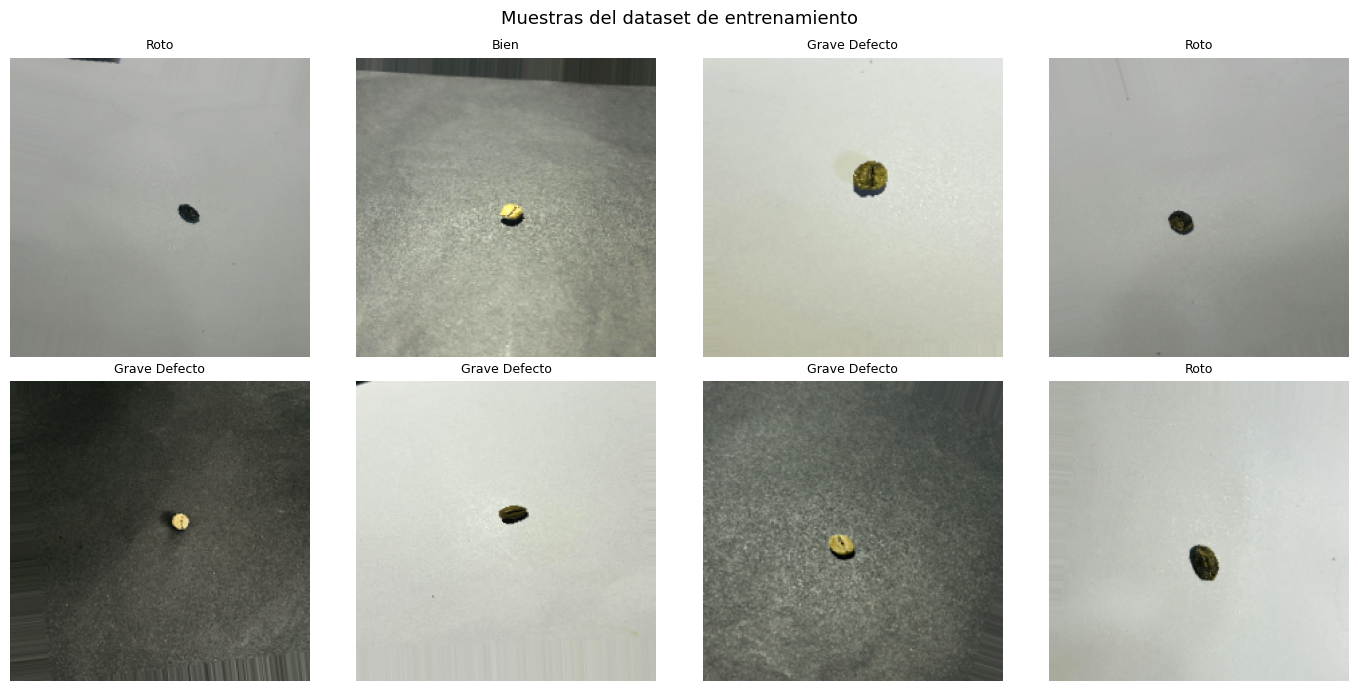

In [6]:
# Aumento de datos solo para entrenamiento
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2]
)

# Validacion y test solo normalización
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    f'{DATASET_DIR}/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    f'{DATASET_DIR}/valid',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_datagen.flow_from_directory(
    f'{DATASET_DIR}/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'Clases detectadas: {train_gen.class_indices}')
print(f'Entrenamiento: {train_gen.samples} imagenes')
print(f'Validacion:    {val_gen.samples} imagenes')
print(f'Test:          {test_gen.samples} imagenes')

# Visualizar muestras del dataset
imgs, labels = next(train_gen)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i])
    clase_idx = np.argmax(labels[i])
    ax.set_title(NOMBRES_CLASES[clase_idx], fontsize=9)
    ax.axis('off')
plt.suptitle('Muestras del dataset de entrenamiento', fontsize=13)
plt.tight_layout()
plt.savefig(f'{EXPORT_DIR}/muestras_dataset.png', dpi=120)
plt.show()

## Celda 6 — Construcción del modelo (Transfer Learning)

In [7]:
# Modelo base preentrenado en ImageNet
base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # congelar capas base

# Capas de clasificacion propias
x      = base_model.output
x      = layers.GlobalAveragePooling2D()(x)
x      = layers.Dense(128, activation='relu')(x)
x      = layers.Dropout(0.3)(x)
salida = layers.Dense(NUM_CLASES, activation='softmax')(x)

modelo = models.Model(inputs=base_model.input, outputs=salida)

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Resumen del modelo
print(f'Parametros totales:    {modelo.count_params():,}')
print(f'Parametros entrenables: {sum([tf.size(w).numpy() for w in modelo.trainable_weights]):,}')
print(f'Parametros congelados:  {sum([tf.size(w).numpy() for w in modelo.non_trainable_weights]):,}')

Parametros totales:    2,422,339
Parametros entrenables: 164,355
Parametros congelados:  2,257,984


## Celda 7 — Fase 1: Entrenamiento de capas propias

In [8]:
callbacks_fase1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        f'{EXPORT_DIR}/mejor_modelo.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

print('=== FASE 1: Entrenando solo capas de clasificacion ===')
historia1 = modelo.fit(
    train_gen,
    epochs=EPOCHS_FASE1,
    validation_data=val_gen,
    callbacks=callbacks_fase1
)

print(f'\nMejor val_accuracy fase 1: {max(historia1.history["val_accuracy"]):.4f}')

=== FASE 1: Entrenando solo capas de clasificacion ===
Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5223 - loss: 1.1457
Epoch 1: val_accuracy improved from None to 0.61340, saving model to /content/drive/MyDrive/clasificador-cafe/exports/mejor_modelo.h5



Epoch 1: finished saving model to /content/drive/MyDrive/clasificador-cafe/exports/mejor_modelo.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 148s 4s/step - accuracy: 0.5296 - loss: 1.0837 - val_accuracy: 0.6134 - val_loss: 0.8921 - learning_rate: 1.0000e-04
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6053 - loss: 0.9699
Epoch 2: val_accuracy improved from 0.61340 to 0.67526, saving model to /content/drive/MyDrive/clasificador-cafe/exports/mejor_modelo.h5



Epoch 2: finished saving model to /content/drive/MyDrive/clasificador-cafe/exports/mejor_modelo.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step - accuracy: 0.6281 - loss: 0.9011 - val_accuracy: 0.6753 - val_loss: 0.8032 - learning_rate: 1.0000e-04
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6636 - loss: 0.8229
Epoch 3: val_accuracy improved from 0.67526 to 0.73196, saving model to /content/drive/MyDrive/clasificador-cafe/exports/mejor_modelo.h5



Epoch 3: finished saving model to /content/drive/MyDrive/clasificador-cafe/exports/mejor_modelo.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 95s 3s/step - accuracy: 0.6520 - loss: 0.8161 - val_accuracy: 0.7320 - val_loss: 0.7812 - learning_rate: 1.0000e-04
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6627 - loss: 0.8179
Epoch 4: val_accuracy improved from 0.73196 to 0.73711, saving model to /content/drive/MyDrive/clasificador-cafe/exports/mejor_modelo.h5



Epoch 4: finished saving model to /content/drive/MyDrive/clasificador-cafe/exports/mejor_modelo.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.6836 - loss: 0.7790 - val_accuracy: 0.7371 - val_loss: 0.7473 - learning_rate: 1.0000e-04
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7111 - loss: 0.6967
Epoch 5: val_accuracy improved from 0.73711 to 0.79897, saving model to /content/drive/MyDrive/clasificador-cafe/exports/mejor_modelo.h5



Epoch 5: finished saving model to /content/drive/MyDrive/clasificador-cafe/exports/mejor_modelo.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - accuracy: 0.6969 - loss: 0.7281 - val_accuracy: 0.7990 - val_loss: 0.7210 - learning_rate: 1.0000e-04
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7268 - loss: 0.6670
Epoch 6: val_accuracy improved from 0.79897 to 0.80412, saving model to /content/drive/MyDrive/clasificador-cafe/exports/mejor_modelo.h5



Epoch 6: finished saving model to /content/drive/MyDrive/clasificador-cafe/exports/mejor_modelo.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 99s 3s/step - accuracy: 0.7161 - loss: 0.6802 - val_accuracy: 0.8041 - val_loss: 0.6543 - learning_rate: 1.0000e-04
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7256 - loss: 0.6747
Epoch 7: val_accuracy did not improve from 0.80412
33/33 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.7275 - loss: 0.6655 - val_accuracy: 0.7887 - val_loss: 0.6650 - learning_rate: 1.0000e-04
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7293 - loss: 0.6746
Epoch 8: val_accuracy improved from 0.80412 to 0.82990, saving model to /content/drive/MyDrive/clasificador-cafe/exports/mejor_modelo.h5



Epoch 8: finished saving model to /content/drive/MyDrive/clasificador-cafe/exports/mejor_modelo.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.7447 - loss: 0.6614 - val_accuracy: 0.8299 - val_loss: 0.6236 - learning_rate: 1.0000e-04
Epoch 9/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7577 - loss: 0.6157
Epoch 9: val_accuracy improved from 0.82990 to 0.84021, saving model to /content/drive/MyDrive/clasificador-cafe/exports/mejor_modelo.h5



Epoch 9: finished saving model to /content/drive/MyDrive/clasificador-cafe/exports/mejor_modelo.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 92s 3s/step - accuracy: 0.7419 - loss: 0.6355 - val_accuracy: 0.8402 - val_loss: 0.6022 - learning_rate: 1.0000e-04
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7538 - loss: 0.6419
Epoch 10: val_accuracy did not improve from 0.84021
33/33 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.7553 - loss: 0.6089 - val_accuracy: 0.8402 - val_loss: 0.6231 - learning_rate: 1.0000e-04
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7576 - loss: 0.6041
Epoch 11: val_accuracy improved from 0.84021 to 0.85567, saving model to /content/drive/MyDrive/clasificador-cafe/exports/mejor_modelo.h5



Epoch 11: finished saving model to /content/drive/MyDrive/clasificador-cafe/exports/mejor_modelo.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step - accuracy: 0.7648 - loss: 0.6007 - val_accuracy: 0.8557 - val_loss: 0.5988 - learning_rate: 1.0000e-04
Epoch 12/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7778 - loss: 0.5741
Epoch 12: val_accuracy did not improve from 0.85567
33/33 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.7658 - loss: 0.5903 - val_accuracy: 0.8454 - val_loss: 0.5958 - learning_rate: 1.0000e-04
Epoch 13/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7803 - loss: 0.5711
Epoch 13: val_accuracy did not improve from 0.85567
33/33 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.7725 - loss: 0.5700 - val_accuracy: 0.8557 - val_loss: 0.5841 - learning_rate: 1.0000e-04
Epoch 14/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7547 - loss: 0.5776
Epoch 14: val_accuracy did not improve from 0.85567
33/33 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - accuracy: 0.7686 - lo

In [9]:
from tensorflow import keras

modelo = keras.models.load_model(
    '/content/drive/MyDrive/clasificador-cafe/exports/mejor_modelo.h5'
)

modelo.save(
    '/content/drive/MyDrive/clasificador-cafe/exports/mejor_modelo.keras'
)

In [10]:
modelo.save(f'{EXPORT_DIR}/modelo_final_855.keras')

## Celda 9 — Curvas de entrenamiento

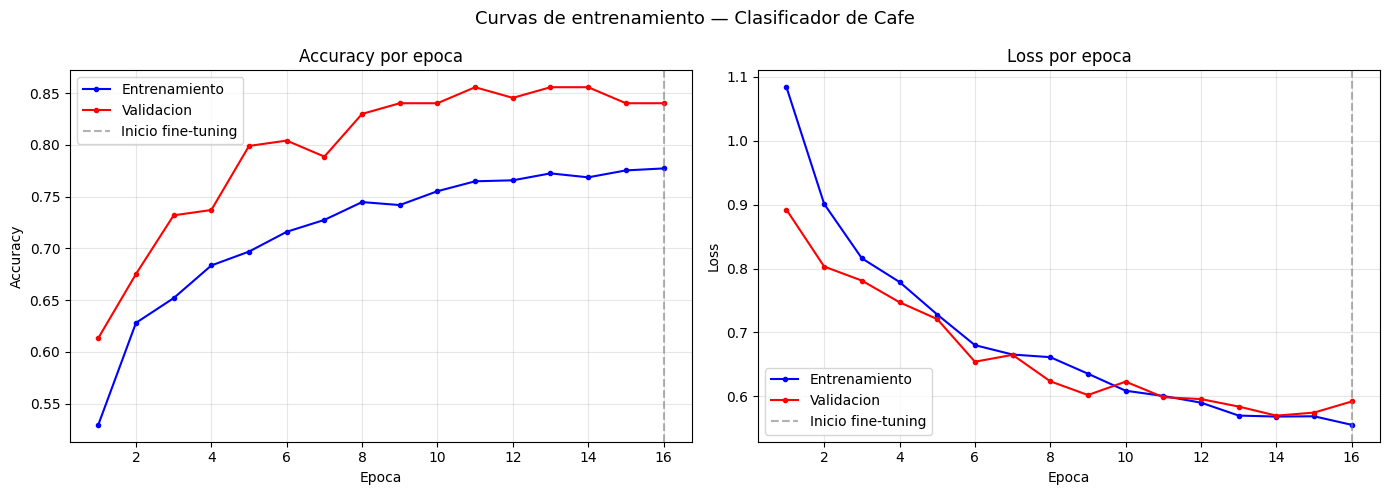

Grafica guardada en Drive


In [12]:
# Combinar historial de las dos fases
acc     = historia1.history['accuracy']
val_acc = historia1.history['val_accuracy']
loss    = historia1.history['loss']       
val_loss= historia1.history['val_loss']     
epochs  = range(1, len(acc) + 1)
corte   = len(historia1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(epochs, acc,     'b-o', markersize=3, label='Entrenamiento')
ax1.plot(epochs, val_acc, 'r-o', markersize=3, label='Validacion')
ax1.axvline(x=corte, color='gray', linestyle='--', alpha=0.6, label='Inicio fine-tuning')
ax1.set_title('Accuracy por epoca')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(epochs, loss,     'b-o', markersize=3, label='Entrenamiento')
ax2.plot(epochs, val_loss, 'r-o', markersize=3, label='Validacion')
ax2.axvline(x=corte, color='gray', linestyle='--', alpha=0.6, label='Inicio fine-tuning')
ax2.set_title('Loss por epoca')
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Curvas de entrenamiento — Clasificador de Cafe', fontsize=13)
plt.tight_layout()
plt.savefig(f'{EXPORT_DIR}/curvas_entrenamiento.png', dpi=150)
plt.show()
print('Grafica guardada en Drive')

## Celda 10 — Evaluación final en el set de test

In [14]:
print('=== EVALUACION EN TEST SET ===')

# Cargar el mejor modelo guardado
mejor_modelo = tf.keras.models.load_model(f'{EXPORT_DIR}/mejor_modelo.keras')

loss, accuracy = mejor_modelo.evaluate(test_gen, verbose=0)
print(f'Loss:     {loss:.4f}')
print(f'Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')

# Predicciones
y_pred_prob = mejor_modelo.predict(test_gen)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_real      = test_gen.classes
confianza   = np.max(y_pred_prob, axis=1)

print(f'\nConfianza promedio: {confianza.mean():.4f} ({confianza.mean()*100:.2f}%)')
print(f'Confianza minima:   {confianza.min():.4f}')
print(f'Confianza maxima:   {confianza.max():.4f}')

# Reporte completo
print('\n=== REPORTE DE CLASIFICACION ===')
print(classification_report(y_real, y_pred, target_names=NOMBRES_CLASES))

# Verificar si cumple mínimos del proyecto
from sklearn.metrics import precision_score, recall_score
precision = precision_score(y_real, y_pred, average='weighted')
recall    = recall_score(y_real, y_pred, average='weighted')

print('=== CUMPLIMIENTO DE RUBRICA ===')
print(f'Accuracy  > 85%: {"OK" if accuracy > 0.85 else "MEJORAR"} ({accuracy*100:.1f}%)')
print(f'Precision > 80%: {"OK" if precision > 0.80 else "MEJORAR"} ({precision*100:.1f}%)')
print(f'Recall    > 80%: {"OK" if recall > 0.80 else "MEJORAR"} ({recall*100:.1f}%)')

=== EVALUACION EN TEST SET ===


Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 


Loss:     0.6471
Accuracy: 0.7483 (74.83%)
10/10 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step

Confianza promedio: 0.6375 (63.75%)
Confianza minima:   0.3547
Confianza maxima:   0.9758

=== REPORTE DE CLASIFICACION ===
               precision    recall  f1-score   support

         Bien       0.54      0.50      0.52        58
Grave Defecto       0.75      0.88      0.81       160
         Roto       0.93      0.68      0.79        84

     accuracy                           0.75       302
    macro avg       0.74      0.68      0.70       302
 weighted avg       0.76      0.75      0.75       302

=== CUMPLIMIENTO DE RUBRICA ===
Accuracy  > 85%: MEJORAR (74.8%)
Precision > 80%: MEJORAR (76.0%)
Recall    > 80%: MEJORAR (74.8%)


## Celda 11 — Matriz de confusión

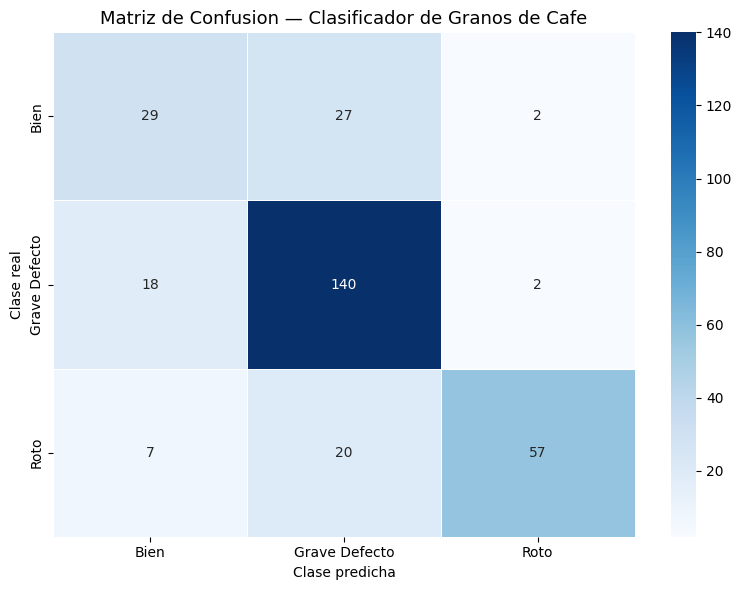

Matriz guardada en Drive


In [15]:
cm = confusion_matrix(y_real, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=NOMBRES_CLASES,
    yticklabels=NOMBRES_CLASES,
    linewidths=0.5
)
plt.title('Matriz de Confusion — Clasificador de Granos de Cafe', fontsize=13)
plt.ylabel('Clase real')
plt.xlabel('Clase predicha')
plt.tight_layout()
plt.savefig(f'{EXPORT_DIR}/matriz_confusion.png', dpi=150)
plt.show()
print('Matriz guardada en Drive')

## Celda 12 — Exportar modelo para producción

In [16]:
# Exportar como TFLite (para n8n en AWS)
converter    = tf.lite.TFLiteConverter.from_keras_model(mejor_modelo)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

ruta_tflite = f'{EXPORT_DIR}/modelo_cafe.tflite'
with open(ruta_tflite, 'wb') as f:
    f.write(tflite_model)

tam_h5     = os.path.getsize(f'{EXPORT_DIR}/mejor_modelo.h5') / 1024 / 1024
tam_tflite = os.path.getsize(ruta_tflite) / 1024 / 1024

print('=== MODELOS EXPORTADOS EN DRIVE ===')
print(f'mejor_modelo.h5      → {tam_h5:.2f} MB  (para desarrollo)')
print(f'modelo_cafe.tflite   → {tam_tflite:.2f} MB  (para produccion en AWS/n8n)')
print(f'\nRuta en Drive: {EXPORT_DIR}')
print('\nArchivos listos para subir al repositorio GitHub')

Saved artifact at '/tmp/tmpi6mzuqfd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132243191260048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132243190236368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132243190235216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132243322696336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132243190240592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132243190239056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132243190235984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132243190235792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132243190238864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132243190237712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132243190236752

## Celda 13 — Prueba de predicción individual

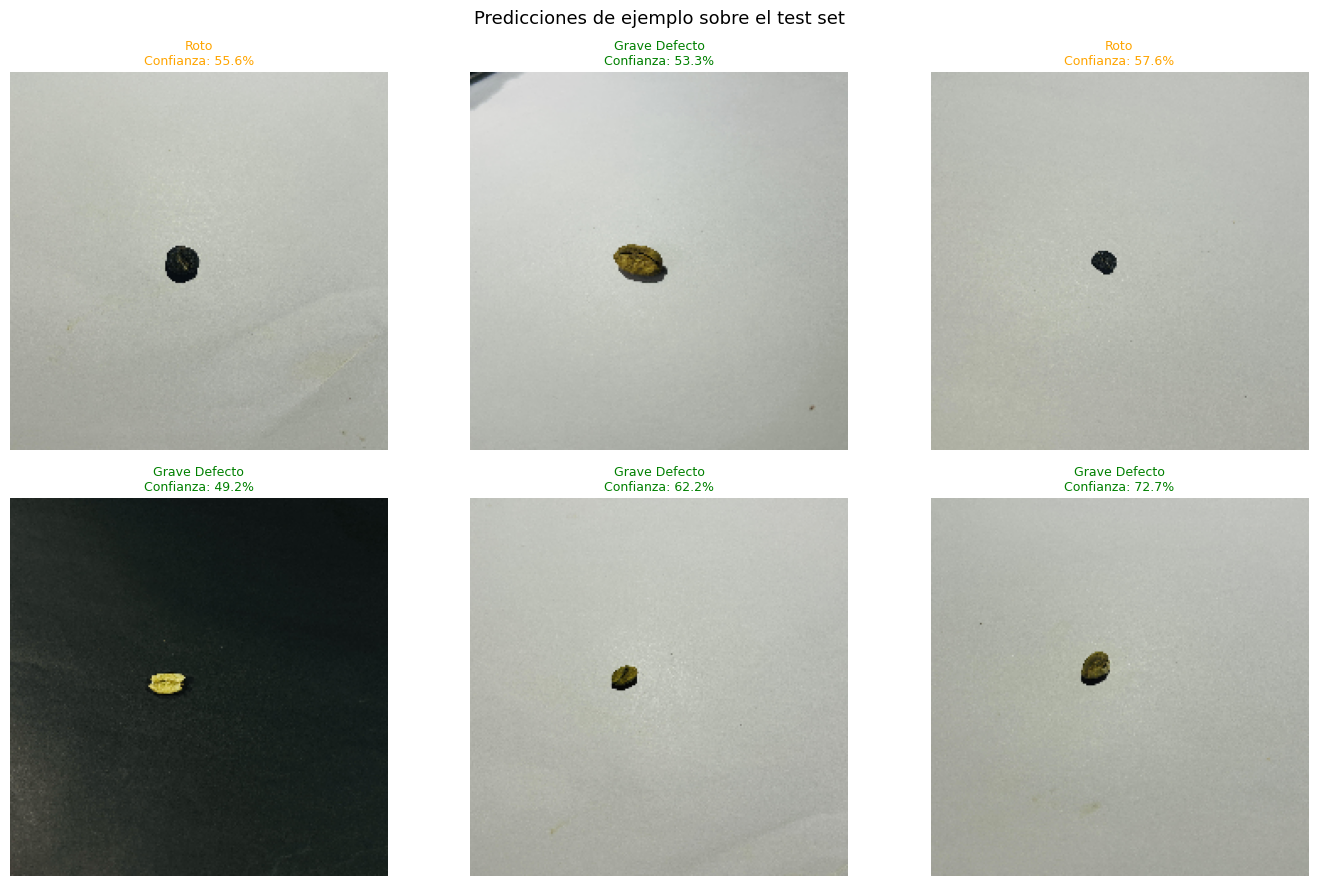

Imagen guardada en Drive

Ejemplo de respuesta JSON que retornara la API:
{
  "clase": 2,
  "nombre": "Roto",
  "confianza": 0.5563400983810425,
  "probabilidades": {
    "Bien": 0.05565918609499931,
    "Grave Defecto": 0.3880006968975067,
    "Roto": 0.5563400983810425
  }
}


In [17]:
from tensorflow.keras.preprocessing import image as keras_image
import random

def predecir_grano(ruta_imagen, modelo):
    img      = keras_image.load_img(ruta_imagen, target_size=IMG_SIZE)
    img_arr  = keras_image.img_to_array(img) / 255.0
    img_arr  = np.expand_dims(img_arr, axis=0)

    prediccion = modelo.predict(img_arr, verbose=0)
    clase      = np.argmax(prediccion)
    confianza  = prediccion[0][clase]

    return {
        'clase': int(clase),
        'nombre': NOMBRES_CLASES[clase],
        'confianza': float(confianza),
        'probabilidades': {
            NOMBRES_CLASES[i]: float(prediccion[0][i])
            for i in range(NUM_CLASES)
        }
    }

# Probar con imágenes aleatorias del test set
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

archivos_test = []
for clase_dir in os.listdir(f'{DATASET_DIR}/test'):
    ruta_clase = f'{DATASET_DIR}/test/{clase_dir}'
    if os.path.isdir(ruta_clase):
        for img_file in os.listdir(ruta_clase)[:2]:
            archivos_test.append(f'{ruta_clase}/{img_file}')

muestra = random.sample(archivos_test, min(6, len(archivos_test)))

for ax, ruta in zip(axes.flat, muestra):
    resultado = predecir_grano(ruta, mejor_modelo)
    img       = keras_image.load_img(ruta, target_size=IMG_SIZE)
    ax.imshow(img)
    color = ['red', 'green', 'orange'][resultado['clase']]
    ax.set_title(
        f"{resultado['nombre']}\nConfianza: {resultado['confianza']*100:.1f}%",
        color=color, fontsize=9
    )
    ax.axis('off')

plt.suptitle('Predicciones de ejemplo sobre el test set', fontsize=13)
plt.tight_layout()
plt.savefig(f'{EXPORT_DIR}/predicciones_ejemplo.png', dpi=150)
plt.show()

print('Imagen guardada en Drive')
print('\nEjemplo de respuesta JSON que retornara la API:')
import json
print(json.dumps(predecir_grano(muestra[0], mejor_modelo), indent=2, ensure_ascii=False))

## Resumen final

Al terminar este notebook tienes en tu Google Drive:

| Archivo | Descripcion |
|---|---|
| `mejor_modelo.h5` | Modelo completo para desarrollo |
| `modelo_cafe.tflite` | Modelo optimizado para produccion (n8n/AWS) |
| `curvas_entrenamiento.png` | Grafica accuracy y loss por epoca |
| `matriz_confusion.png` | Matriz de confusion 3x3 |
| `predicciones_ejemplo.png` | Predicciones visuales sobre el test set |
| `muestras_dataset.png` | Muestras del dataset de entrenamiento |

**Siguiente paso:** Subir `modelo_cafe.tflite` a AWS EC2 y configurar el workflow de n8n.

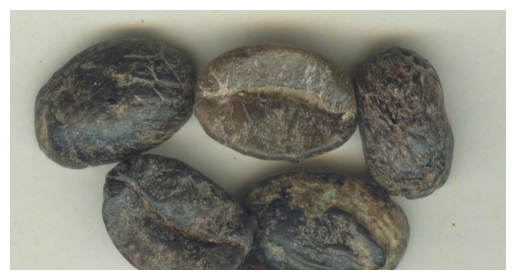

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Clase predicha: Grave Defecto
Confianza: 0.4092218279838562
Bien: 29.18%
Grave Defecto: 40.92%
Roto: 29.89%


In [18]:
import requests
from PIL import Image
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# URL de imagen de internet
url = "https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEg8XB2Sax6bXS7n26IvV1wm2lL_07cW4qe997KQR7X_q685kyj-ccTw_xqB7Pq06k1mqMPzWTXX9NosG62DXo8s1I5HCVD7S7t1Wj3Sb5MftkdJrk4otZ3W5UaEx3KSiGxD40FcZxYuilTP/w1200-h630-p-k-no-nu/Negros+1.jpg"

# Descargar imagen
img_data = requests.get(url).content

# Guardar temporalmente
with open("imagen_prueba.jpg", "wb") as handler:
    handler.write(img_data)

# Mostrar imagen
img = Image.open("imagen_prueba.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

# Preprocesamiento
img = img.resize((224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predicción
pred = modelo.predict(img_array)

# Clases
clases = ['Bien', 'Grave Defecto', 'Roto']

# Resultado
clase_idx = np.argmax(pred)
confianza = float(np.max(pred))

print("Clase predicha:", clases[clase_idx])
print("Confianza:", confianza)

# Probabilidades
for i, clase in enumerate(clases):
    print(f"{clase}: {pred[0][i]*100:.2f}%")

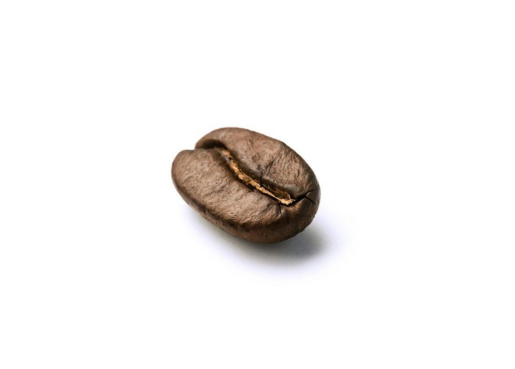

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Clase predicha: Grave Defecto
Confianza: 0.8984483480453491
Bien: 4.47%
Grave Defecto: 89.84%
Roto: 5.68%


In [19]:
import requests
from PIL import Image
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# URL de imagen de internet
url = "https://incapto.com/wp-content/uploads/2020/07/Grano-Caf%C3%A9-e1595004468546.jpg"

# Descargar imagen
img_data = requests.get(url).content

# Guardar temporalmente
with open("imagen_prueba.jpg", "wb") as handler:
    handler.write(img_data)

# Mostrar imagen
img = Image.open("imagen_prueba.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

# Preprocesamiento
img = img.resize((224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predicción
pred = modelo.predict(img_array)

# Clases
clases = ['Bien', 'Grave Defecto', 'Roto']

# Resultado
clase_idx = np.argmax(pred)
confianza = float(np.max(pred))

print("Clase predicha:", clases[clase_idx])
print("Confianza:", confianza)

# Probabilidades
for i, clase in enumerate(clases):
    print(f"{clase}: {pred[0][i]*100:.2f}%")

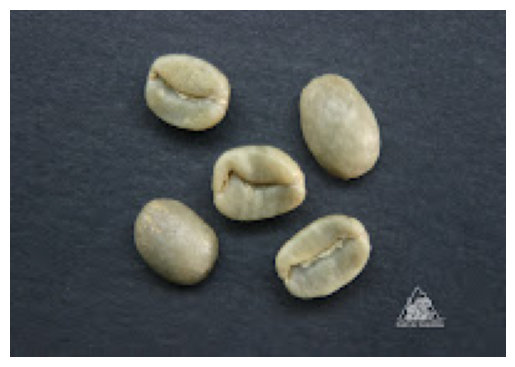

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Clase predicha: Grave Defecto
Confianza: 0.7082461714744568
Bien: 26.26%
Grave Defecto: 70.82%
Roto: 2.91%


In [20]:
import requests
from PIL import Image
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# URL de imagen de internet
url = "https://1.bp.blogspot.com/-ai63Ptke7K8/T0WZ2KiITEI/AAAAAAAAAPA/03gTo9_twTs/s200/8+Decolorado+sobresecado+MDA.jpg"

# Descargar imagen
img_data = requests.get(url).content

# Guardar temporalmente
with open("imagen_prueba.jpg", "wb") as handler:
    handler.write(img_data)

# Mostrar imagen
img = Image.open("imagen_prueba.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

# Preprocesamiento
img = img.resize((224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predicción
pred = modelo.predict(img_array)

# Clases
clases = ['Bien', 'Grave Defecto', 'Roto']

# Resultado
clase_idx = np.argmax(pred)
confianza = float(np.max(pred))

print("Clase predicha:", clases[clase_idx])
print("Confianza:", confianza)

# Probabilidades
for i, clase in enumerate(clases):
    print(f"{clase}: {pred[0][i]*100:.2f}%")

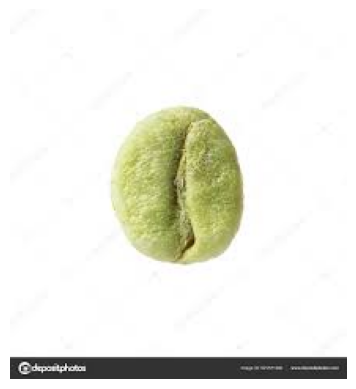

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Clase predicha: Grave Defecto
Confianza: 0.7541720867156982
Bien: 19.70%
Grave Defecto: 75.42%
Roto: 4.88%


In [21]:
import requests
from PIL import Image
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# URL de imagen de internet
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRSaOfbxs8xxTdZIAuBpYf0rZMZpHdfPihNCA&s"

# Descargar imagen
img_data = requests.get(url).content

# Guardar temporalmente
with open("imagen_prueba.jpg", "wb") as handler:
    handler.write(img_data)

# Mostrar imagen
img = Image.open("imagen_prueba.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

# Preprocesamiento
img = img.resize((224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predicción
pred = modelo.predict(img_array)

# Clases
clases = ['Bien', 'Grave Defecto', 'Roto']

# Resultado
clase_idx = np.argmax(pred)
confianza = float(np.max(pred))

print("Clase predicha:", clases[clase_idx])
print("Confianza:", confianza)

# Probabilidades
for i, clase in enumerate(clases):
    print(f"{clase}: {pred[0][i]*100:.2f}%")

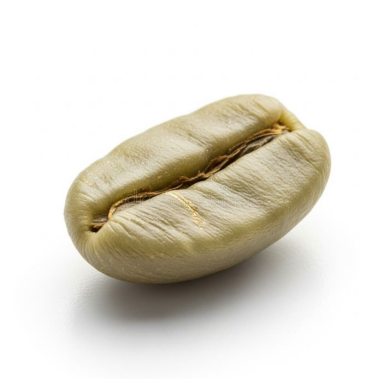

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Clase predicha: Grave Defecto
Confianza: 0.7845274209976196
Bien: 9.97%
Grave Defecto: 78.45%
Roto: 11.58%


In [22]:
import requests
from PIL import Image
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# URL de imagen de internet
url = "https://thumbs.dreamstime.com/b/un-solo-grano-de-caf%C3%A9-verde-sin-tostar-con-una-profunda-hendidura-sobre-fondo-blanco-cafe%C3%ADna-420435468.jpg"

# Descargar imagen
img_data = requests.get(url).content

# Guardar temporalmente
with open("imagen_prueba.jpg", "wb") as handler:
    handler.write(img_data)

# Mostrar imagen
img = Image.open("imagen_prueba.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

# Preprocesamiento
img = img.resize((224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predicción
pred = modelo.predict(img_array)

# Clases
clases = ['Bien', 'Grave Defecto', 'Roto']

# Resultado
clase_idx = np.argmax(pred)
confianza = float(np.max(pred))

print("Clase predicha:", clases[clase_idx])
print("Confianza:", confianza)

# Probabilidades
for i, clase in enumerate(clases):
    print(f"{clase}: {pred[0][i]*100:.2f}%")